# Controlling the mesh construction process

## Overview
In the [tutorial on single phase flow](./single_phase_flow.ipynb), we saw an example of how to specify the geometry of fractures and domain, and how to generate mixed-dimensional grids. In this tutorial, we will give more details on how to control the meshing process and the resulting mesh. 
The main focus is on the creation of unstructured meshes, as the flexibility they offer is necessary to adapt to complex fracture geometries.
To create meshes that provide a decent resolution of the geometry with a limited amount of cells may require some tweaking of mesh size parameters, and we will review the possibilities to do so within PorePy.
Towards the end, we will also briefly show how to generate structured (Cartesian) meshes for fracture networks with a sufficiently structured geometry.

## Geometry specification and the creation of uniform meshes
We start by defining the geometry, and consider the unit square with two non-intersecting fractures embedded. Specifying the geometry was already covered in the tutorial on single phase flow, see there for details. Contrary to that tutorial, we do not specify the grid type and cell size by overriding the methods `grid_type` and `meshing_arguments`. Instead, we will control these parameters by the parameter dictionary. 

To create a fully functional model, we combine the geometry specification with the single phase flow model. This choice is arbitrary, we could have used any of the models for the purposes of this tutorial.

In [1]:
import numpy as np
import porepy as pp
from porepy.applications.md_grids.domains import nd_cube_domain

# Define a units object to handle unit conversions. Here we use meters as base unit,
# hence the default length unit is "m" and the conversion will have no practical effect.
# Nevertheless, it is good practice to use the units framework to ensure consistency.
units = pp.Units()

class ModifiedGeometry:
    def set_domain(self) -> None:
        """Defining a two-dimensional unit square domain."""
        size = self.units.convert_units(1, "m")
        self._domain = nd_cube_domain(2, size)

    def set_fractures(self) -> None:
        """Set two fractures: One horizontal and one vertical."""
        frac_1_points = self.units.convert_units(
            np.array([[0.2, 0.7], [0.3, 0.3]]), "m"
        )
        frac_1 = pp.LineFracture(frac_1_points)
        frac_2_points = self.units.convert_units(
            np.array([[0.2, 0.6], [0.4, 0.4]]), "m"
        )
        frac_2 = pp.LineFracture(frac_2_points)
        self._fractures = [frac_1, frac_2]


# Create a full model.
class ModifiedModel(ModifiedGeometry, pp.SinglePhaseFlow):
    pass


def mesh_and_plot(model_class, params):
    # Helper function to mesh and plot the mixed-dimensional grid from a model class
    # and a set of parameters.

    # Add the units to the parameters.
    params["units"] = units

    # Instantiate the model.
    model = model_class(params)
    # Set the geometry. This will generate the mesh, resulting in an attribute 'mdg'
    # (MixedDimensionalGrid) being created in the model.
    model.set_geometry()
    # Get the mixed-dimensional grid.
    pp.plot_grid(
        model.mdg, figsize=(10, 8),
        plot_2d=True,
        fracturewidth_1d=3,
        linewidth=0.5,
        title="Mixed-dimensional grid",
        rgb=[0.8, 0.8, 0.8],
    )

Now we can make the model generate a mesh 

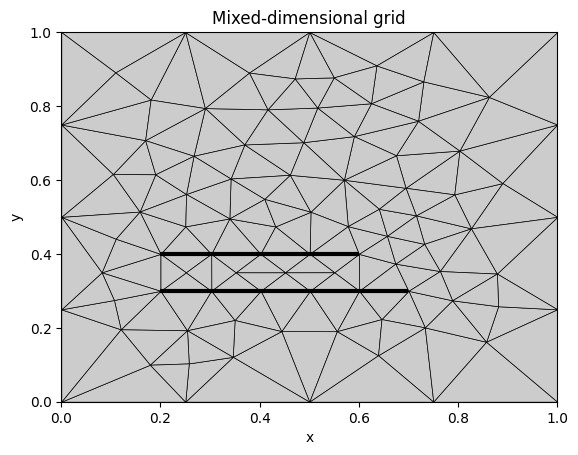

In [2]:
params = {"grid_type": "simplex",
          "meshing_arguments": {"cell_size": units.convert_units(0.25, "m")}}
mesh_and_plot(ModifiedModel, params)


Some comments are in order:
1. The mesh is constructed by the software [Gmsh](https://gmsh.info/), which is an advanced tool for mesh generation used for the actual mesh construction. PorePy automatically translates the geometry specification to Gmsh and reads and post-processes the generated mesh. It is rarely needed for PorePy users to directly interact with Gmsh.
2. Although the mesh size was specified to 0.25, the actual cells size is somewhat different. It is not uncommon that mesh size parameters specified on the PorePy side are only partly reflected in the constructed mesh. This is in part due to the inner workings of PorePy's mesh size control, but it can also be caused by the specified geometry. For instance, to resolve the gap betweeen two almost intersecting fractures, small cells are needed, and Gmsh may decide to disregard a wish for large cells in that region. Tuning the mesh size is an art that needs some practice.

## Different mesh resolution on fractures and boundary
As seen above, the parameter `cell_size` sets a uniform cell size for the entire domain. In practice it may be desirable to focus the mesh resolution, hence the computational effort, in the vicinity of the fractures. For that, PorePy allows for setting a background cell size as well as a cell size on fractures. The background mesh size, which for historical reasons is controlled by the parameter `cell_size_boundary`, can be considered the default cell size which is assigned when no other constraints apply. The cell size on fractures is controlled by the parameter `cell_size_fracture`. If not provided, both `cell_size_boundary` and `cell_size_fracture` will default to `cell_size`.

By assigning different values for `cell_size_boundary` and `cell_size_fracture` we can produce a mesh which is refined in a region around the fracture:

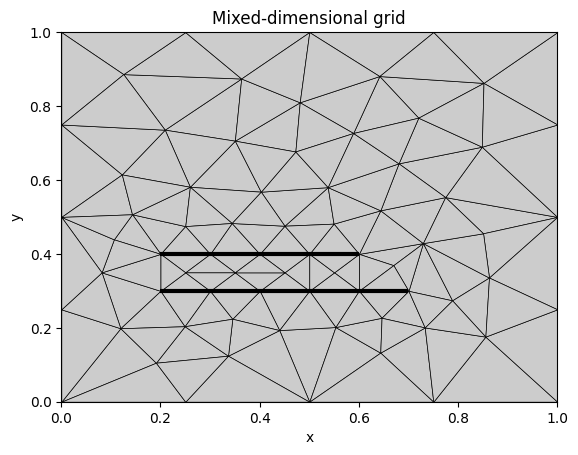

In [3]:
params = {
    "grid_type": "simplex",
    "meshing_arguments": {
        "cell_size_fracture": units.convert_units(0.1, "m"),
        "cell_size_boundary": units.convert_units(0.3, "m"),
    },
}
mesh_and_plot(ModifiedModel, params)

It should be mentioned that the mesh size algorithm sometimes can give unexpected results in the form of meshes with poor quality or with a higher than expected cell count.
It is therefore good practice to inspect the mesh before starting costly simulation.

## Advanced mesh size control
To better control the mesh quality, it may be desirable to give more detailed instructions for the the mesh size control in the vicinity of fractures. 
To that end, PorePy offers two mechanisms:
1. The user can control what is meant by 'vicinity', that is, how close two objects must be to trigger mesh refinement.
2. The mesh size will transit gradually from the fracture to the far-field (boundary) value. Again, the user can control how aggresive this transition is.

In this section, we will discuss how this can be used to impact mesh refinement around fractures. The relevant parameters are assigned default values that are meant to give reasonable behavior for many cases, hence, the functionality discussed below can be considered advanced usage.

### Triggering refinement near proximate fractures
Since isolated fractures will be assigned the target fracture mesh size, the threshold for refinement is set relative to this target. By default, this value is `1.0`, that is, two geometric objects need to be closer than the target mesh size to trigger mesh refinement. We can override this by providing an argument `refinement_proximity_multiplier`. This threshold scales with the fracture cell size; for instance, if we set `refinement_proximity_multiplier=2.0` and keep `cell_size_fracture=0.1`, geometric objects with a distance less than `0.2` will trigger the refinement procedure. 

If refinement is triggered, a local mesh size will be computed as the minimum between the distance and `cell_size_fracture` (special rules apply if the fractures are crossing). 


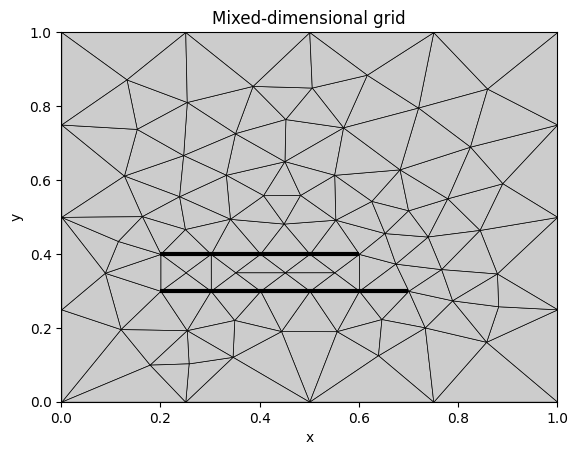

In [4]:
params = {
    "grid_type": "simplex",
    "meshing_arguments": {
        # The target fracture mesh size is set larger than the distance between
        # fractures.
        "cell_size_fracture": units.convert_units(0.15, "m"),
        "cell_size_boundary": units.convert_units(0.3, "m"),
        # The target fracture cell size is 0.15 and the default refinement threshold of
        # 1.0 will trigger refinement on the fractures (that are 0.1 apart). We modify
        # it here to illustrate the option.
        # NOTE: We can switch off refinement triggered by fracture proximity by reducing
        # the refinement threshold. For that, set the value to, say, 0.5 instead.
        "refinement_proximity_multiplier": 2.0,
    },
}
mesh_and_plot(ModifiedModel, params)


To better control the mesh in the vicinity of fractures that are closer than the proximity threshold, the parameter `refinement_size_multiplier` can be used to scale the local mesh size, that is, the minimum of the fracture distance and `cell_size_fracture`. By default, `refinement_size_multiplier=1.0`, hence it has no impact on the mesh.

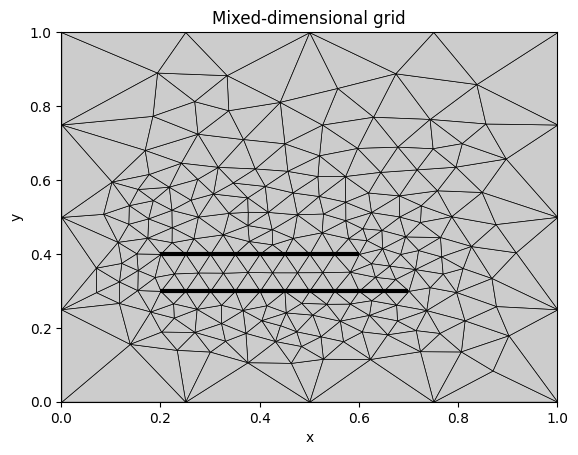

In [5]:
params = {
    "grid_type": "simplex",
    "meshing_arguments": {
        # The target fracture mesh size is set larger than the distance between
        # fractures. Refinement is triggered by the default refinement threshold.
        "cell_size_fracture": units.convert_units(0.15, "m"),
        "cell_size_boundary": units.convert_units(0.3, "m"),
        # Request a halving of the cell along the proximate fractures. This will also
        # affect cells in the region surrounding the fractures.
        "refinement_size_multiplier": 0.5,
    },
}
mesh_and_plot(ModifiedModel, params)


### Transitioning to the background cell size
When the mesh is refined close to fractures the mesh will gradually coarsen as we move away from the fracture, until, when far enough away, `cell_size_boundary` is reached. The size of this transition region, which can have a significant impact on the computational cost, can be controlled by the parameter `background_transition_multiplier`, which is automatically scaled by `cell_size_fracture`. By default, `background_transition_multiplier=10.0`, and it cannot be set lower than slightly larger than 1.0 (with lower values, there would be no coarsening away from the fracture). The following example illustrates this in pratice:

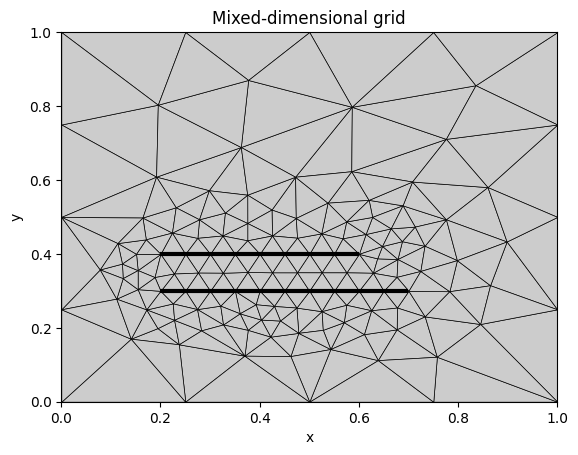

In [6]:
params = {
    "grid_type": "simplex",
    "meshing_arguments": {
        # The target fracture mesh size is set larger than the distance between
        # fractures. Refinement is triggered by the default refinement threshold.
        "cell_size_fracture": units.convert_units(0.15, "m"),
        "cell_size_boundary": units.convert_units(0.3, "m"),
        # Request a halving of the cell along the proximate fractures. This will also
        # affect cells in the region surrounding the fractures.
        "refinement_size_multiplier": 0.5,
        # Set a far-field transition factor which is lower than the default value,
        # leading to a quicker coarsening of the mesh away from the fractures.
        "background_transition_multiplier": 3.0,
    },
}
mesh_and_plot(ModifiedModel, params)


We make two final comments on mesh size control:
1. PorePy does not offer the possibility to set different refinement options for different parts of the domain (different fractures, say). To do this, it is necessary to interact directly with Gmsh and then import the resulting mesh.
2. For parameters that correspond to aggressive coarsening away from fractures, Gmsh may produce low quality meshes. In these cases, it is necessary either to modify the parameters or try to control the meshing process directly in Gmsh. It is good practice to inspect the generated mesh before starting heavy computations.

### Other parameters
To avoid overly refined meshes, the minimum mesh size can be controled through the parameter `cell_size_min`. By default, this is set to `0.1 * min(cell_size_boundary, cell_size_fracture)`. We reiterate that Gmsh may decide to override such settings.

Out of Gmsh's many parameters, PorePy supports directly controlling the few that have the largest impact on the meshing process. The meshing algorithm is controlled through the parameter `meshing_algorithm`. For an overview of the available options, see the Gmsh manual. By default, PorePy uses the 'Delaunay' and 'HXT' algorithms for 2d and 3d domains, respectively. We note that while the Gmsh manual generally recommends the 'Frontal-Delaunay' algorithm for 2d domains, the pure 'Delaunay' algorithm is considered more robust for complex mesh size fields. 

Gmsh supports parallelization through OpenMP and PorePy allows the user to enable this through the option `num_processors`. This can substantially speed up the mesh construction, in particular for complex domains with many cells. Be aware that, when multiple processors are employed, the mesh construction is no longer deterministic. For this reason, PorePy by default assigns a single processor to Gmsh.

For certain combinations of geometries and mesh size parameters, mesh refinement on the domain boundary can make the boundary mesh considerably finer than the mesh size in the interior. The mesh size in the interior can be constrained by that on the boundary by setting the parameter `extend_mesh_size_from_boundary` to `True` (the default is `False`). This may substantially increase the cell count and should only be done after visual inspection of the mesh.

It is sometimes useful to get progress reports from Gmsh. This can be controlled through the parameter `gmsh_verbosity_level`; see the Gmsh manual for information.

To illustrate the use of these parameters, we consider a geometry with 10 fractures; for more information on this case, see the [tutorial on benchmark simulations](https://github.com/pmgbergen/porepy/blob/develop/tutorials/benchmark_simulation.ipynb).
Note that the extra parameters are mainly passed as `meshing_kwargs`. The exception is `cell_size_min`, which for historical reasons is passed in `meshing_arguments`. We illustrate the use of these keywords below:

Info    : Writing 'gmsh_frac_file.geo_unrolled'...                                                                                  
Info    : Done writing 'gmsh_frac_file.geo_unrolled'
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [  0%] Meshing curve 3 (Line)
Info    : [  0%] Meshing curve 2 (Line)
Info    : [  0%] Meshing curve 4 (Line)
Info    : [  0%] Meshing curve 7 (Line)
Info    : [  0%] Meshing curve 10 (Line)
Info    : [ 20%] Meshing curve 13 (Line)
Info    : [ 20%] Meshing curve 14 (Line)
Info    : [ 20%] Meshing curve 15 (Line)
Info    : [ 30%] Meshing curve 16 (Line)
Info    : [ 30%] Meshing curve 17 (Line)
Info    : [ 30%] Meshing curve 18 (Line)
Info    : [ 30%] Meshing curve 19 (Line)
Info    : [ 30%] Meshing curve 20 (Line)
Info    : [ 30%] Meshing curve 21 (Line)
Info    : [ 60%] Meshing curve 22 (Line)
Info    : [ 60%] Meshing curve 23 (Line)
Info    : [ 60%] Meshing curve 24 (Line)
Info    : [ 70%] Meshing curve 25 (Line)
Info    : [ 70%]

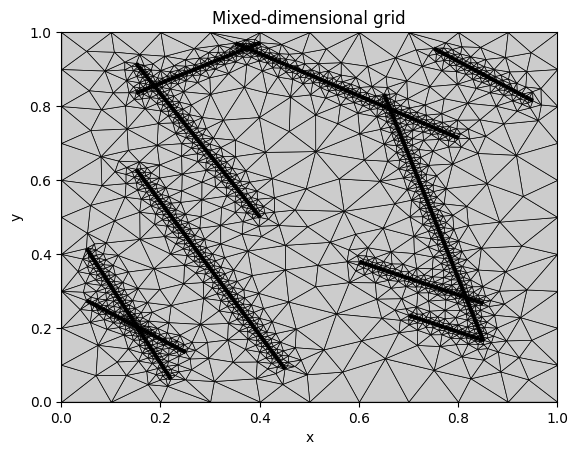

In [7]:
from porepy.examples.flow_benchmark_2d_case_3 import FlowBenchmark2dCase3aModel


params = {
    "grid_type": "simplex",
    "meshing_arguments": {
        # Let the fracture mesh size be an order of magnitude smaller than the
        # boundary mesh size.
        "cell_size_fracture": units.convert_units(0.01, "m"),
        "cell_size_boundary": units.convert_units(0.1, "m"),
        # Set a low minimum cell size.
        "cell_size_min": units.convert_units(0.005, "m"),
    },
    "meshing_kwargs": {
        # This is how to use the 'Frontal Delaunay' meshing algorithm in Gmsh.
        "meshing_algorithm": 5,
        # Use 4 processors for the meshing.
        "num_processors": 4,
        # Make Gmsh more verbose in its output.
        "gmsh_verbosity_level": 5,
        # Do not extend the mesh size from the boundary. Set this to True to see the
        # difference (this is most likely not desired here).
        "extend_mesh_size_from_boundary": False,
    },
}
mesh_and_plot(FlowBenchmark2dCase3aModel, params)

Inspection of the Gmsh output shows that the wall clock time spent on 1d meshing is about a quarter of the CPU time, indicating that multiprocessing was activated by Gmsh. How effective Gmsh's parallelization is can be highly problem specific.


## Meshing of 3d domains
Meshing of 3d domains is steered by the same keywords as for 2d. We make some comments:
1. In regions between close, possibly intersecting, fractures, Gmsh has a tendency to create badly shaped cells. This can be counteracted by reducing the parameter `refinement_buffer`. It is advisable to inspect the generated meshes in such regions before starting costly simulations.
2. When tuning mesh quality keep in mind that, compared to 2d domains, the cell count in 3d may increase surprisingly fast under refinement or when adding more fractures. 

# Loading of previously generated grids
For domains with a large number of fractures or a fine grid, mesh construction can consume a considerable amount of time.
It can be useful to avoid generating the same grid over and over again when running multiple simulations on the same geometry.
This can be achieved by reusing a previously generated `MixedDimensionalGrid`. To do that, we need to include the mixin `LoadGeometryMixin` in our model:

In [8]:
class LoadableModel(pp.models.geometry.LoadGeometryMixin, ModifiedModel):
    pass

params = {
    "grid_type": "simplex",
    "meshing_arguments": {
        "cell_size": units.convert_units(0.1, "m"),
    },
    "units": units
}

# Instantiate the model.
model = LoadableModel(params)
# Call a method provided by the LoadGeometryMixin to create the geometry and export it
# to a file.
model.create_and_export_geometry()

# Create a new model instance and load the geometry from the file created by the first
# model.
model_2 = LoadableModel(params)
# Now call the LoadGeometriMixin version of set_geometry. Instead of generating a mesh
# through Gmsh, this will load the geometry from the file created by the first model and
# create the mixed-dimensional grid (mdg) in the model_2 instance.
model_2.set_geometry()

# To illustrate that the geometries indeed are the same, we can compare the cell centers
# of the first subdomain (for the current problem, this will be the 2D domain) in the
# two models.
assert np.allclose(model.mdg.subdomains()[0].cell_centers, model_2.mdg.subdomains()[0].cell_centers)

# Cartesian meshes
In cases where the domain is box-shaped (both 2d and 3d) and all fractures align with the coordinate axes, PorePy supports Cartesian meshes that conform to the fractures. For our domain, we can achieve this through the following parameters:

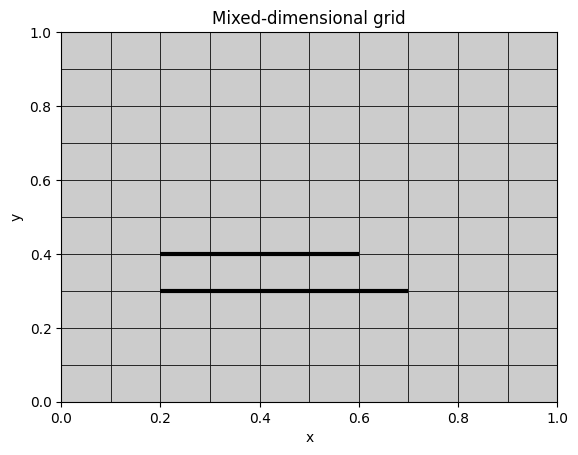

In [9]:
params = {
    "grid_type": "cartesian",
    "meshing_arguments": {
        "cell_size": units.convert_units(0.1, "m"),
    },
    # Add the units to the parameters.
    "units": units
}
mesh_and_plot(ModifiedModel, params)




Note that we here control the cell cells through the parameter `cell_size`, the parameters `cell_size_boundary` and `cell_size_fracture` will not be seen under Cartesian meshing. It is possible to construct tensor product grids with non-uniform cells, but this is considered advanced functionality.

# What we have explored
PorePy generates meshes through a backport to the software Gmsh. PorePy provides parameters that allow for refinement of the mesh close to fractures and areas of geometric complexity. Constructing high quality meshes with a limited number of cells may require some trial and error, and it is good practice to inspect the generated mesh before starting computationally demanding simulations.